In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Dataset downloaded to:", path)

100%|██████████████████████████████████████████████████████████████████████████████| 66.0M/66.0M [03:37<00:00, 317kB/s]

Extracting files...


Dataset downloaded to: C:\Users\dell\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [6]:
import os

path = r"C:\Users\dell\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3"

print(os.listdir(path))

['creditcard.csv']


In [7]:
import pandas as pd

file_path = r"C:\Users\dell\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3\creditcard.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [10]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [11]:
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [12]:
print("Normal transactions:", (df["Class"] == 0).sum())
print("Fraud transactions:", (df["Class"] == 1).sum())

Normal transactions: 284315
Fraud transactions: 492


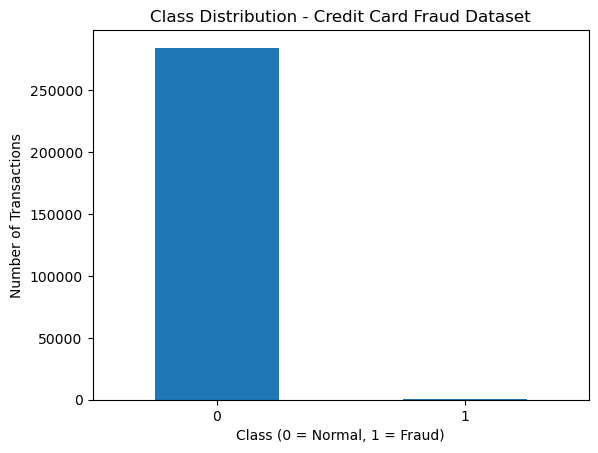

In [13]:
import matplotlib.pyplot as plt

df["Class"].value_counts().plot(kind="bar")

plt.title("Class Distribution - Credit Card Fraud Dataset")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

The target variable is highly imbalanced. There are 284,315 normal transactions (99.83%) and only 492 fraudulent transactions (0.17%). Therefore, fraud cases represent a very small minority of the dataset

In [14]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 30)
Testing data: (56962, 30)


In [16]:
#Base line logistic Regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [17]:
y_pred = baseline_model.predict(X_test)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.9991
Precision: 0.8267
Recall   : 0.6327
F1 Score : 0.7168


In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[56851    13]
 [   36    62]]


In [20]:
import imblearn

print(imblearn.__version__)

0.13.0


In [21]:
from imblearn.over_sampling import SMOTE

In [22]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [23]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

smote_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

smote_model.fit(X_train_smote, y_train_smote)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [25]:
y_pred_smote = smote_model.predict(X_test)

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)

print("SMOTE Model Results")
print("-------------------")
print("Accuracy :", round(accuracy_smote, 4))
print("Precision:", round(precision_smote, 4))
print("Recall   :", round(recall_smote, 4))
print("F1 Score :", round(f1_smote, 4))

SMOTE Model Results
-------------------
Accuracy : 0.9899
Precision: 0.1341
Recall   : 0.898
F1 Score : 0.2334


In [27]:
from sklearn.metrics import confusion_matrix

cm_smote = confusion_matrix(y_test, y_pred_smote)

print(cm_smote)

[[56296   568]
 [   10    88]]


SMOTE increased Recall from 63.27% → 89.80%, meaning it detected many more fraud cases, but Precision dropped from 82.67% → 13.41% because it produced many more false alarms.


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

weighted_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

weighted_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [29]:
y_pred_weighted = weighted_model.predict(X_test)

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
precision_weighted = precision_score(y_test, y_pred_weighted)
recall_weighted = recall_score(y_test, y_pred_weighted)
f1_weighted = f1_score(y_test, y_pred_weighted)

print("Class-Weighted Model Results")
print("----------------------------")
print("Accuracy :", round(accuracy_weighted, 4))
print("Precision:", round(precision_weighted, 4))
print("Recall   :", round(recall_weighted, 4))
print("F1 Score :", round(f1_weighted, 4))

Class-Weighted Model Results
----------------------------
Accuracy : 0.9755
Precision: 0.061
Recall   : 0.9184
F1 Score : 0.1144


In [31]:
from sklearn.metrics import confusion_matrix

cm_weighted = confusion_matrix(y_test, y_pred_weighted)

print(cm_weighted)

[[55478  1386]
 [    8    90]]


In [32]:
from sklearn.metrics import roc_auc_score

# Probability predictions
y_prob_baseline = baseline_model.predict_proba(X_test)[:, 1]
y_prob_smote = smote_model.predict_proba(X_test)[:, 1]
y_prob_weighted = weighted_model.predict_proba(X_test)[:, 1]

# ROC-AUC
auc_baseline = roc_auc_score(y_test, y_prob_baseline)
auc_smote = roc_auc_score(y_test, y_prob_smote)
auc_weighted = roc_auc_score(y_test, y_prob_weighted)

print("Baseline ROC-AUC:", round(auc_baseline, 4))
print("SMOTE ROC-AUC:", round(auc_smote, 4))
print("Class-Weighted ROC-AUC:", round(auc_weighted, 4))


Baseline ROC-AUC: 0.9605
SMOTE ROC-AUC: 0.9765
Class-Weighted ROC-AUC: 0.9721


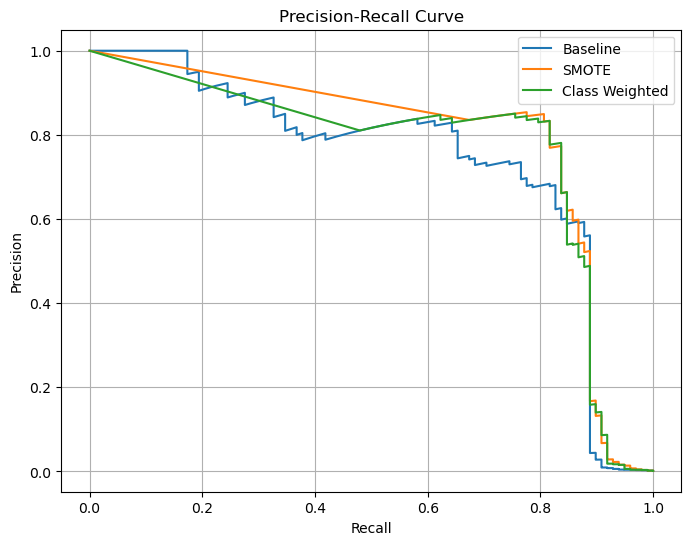

In [33]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision_b, recall_b, _ = precision_recall_curve(y_test, y_prob_baseline)
precision_s, recall_s, _ = precision_recall_curve(y_test, y_prob_smote)
precision_w, recall_w, _ = precision_recall_curve(y_test, y_prob_weighted)

plt.figure(figsize=(8, 6))

plt.plot(recall_b, precision_b, label="Baseline")
plt.plot(recall_s, precision_s, label="SMOTE")
plt.plot(recall_w, precision_w, label="Class Weighted")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

In [34]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "SMOTE",
        "Class Weighted"
    ],
    "Accuracy": [
        accuracy,
        accuracy_smote,
        accuracy_weighted
    ],
    "Precision": [
        precision,
        precision_smote,
        precision_weighted
    ],
    "Recall": [
        recall,
        recall_smote,
        recall_weighted
    ],
    "F1 Score": [
        f1,
        f1_smote,
        f1_weighted
    ],
    "ROC-AUC": [
        auc_baseline,
        auc_smote,
        auc_weighted
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline,0.999140,0.826667,0.632653,0.716763,0.960549
1,SMOTE,0.989853,0.134146,0.897959,0.233422,0.976482
2,Class Weighted,0.975528,0.060976,0.918367,0.114358,0.972083


In [35]:
results.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1 Score": "{:.2%}",
    "ROC-AUC": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline,99.91%,82.67%,63.27%,71.68%,0.9605
1,SMOTE,98.99%,13.41%,89.80%,23.34%,0.9765
2,Class Weighted,97.55%,6.10%,91.84%,11.44%,0.9721


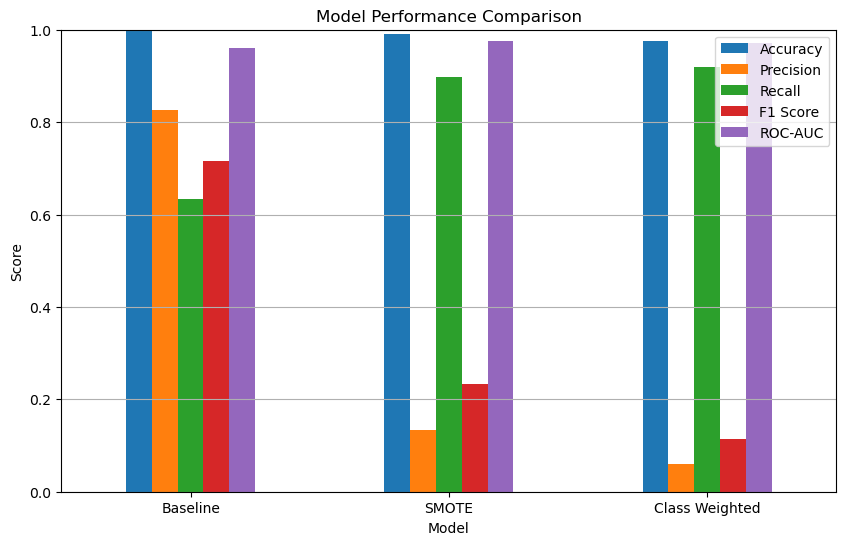

In [36]:
results.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]].plot(kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y")
plt.show()

The Credit Card Fraud Detection dataset was found to be extremely imbalanced, with fraudulent transactions representing only 0.17% of all transactions.

The baseline Logistic Regression model achieved an accuracy of 99.91%, but its recall was only 63.27%, demonstrating that high accuracy does not necessarily indicate effective fraud detection.

Two imbalance-handling approaches were then evaluated: SMOTE and class weighting.

SMOTE increased recall from 63.27% to 89.80% and achieved the highest ROC-AUC of 0.9765. Class weighting achieved the highest recall of 91.84%, but produced a very large number of false positives and had a precision of only 6.10%.

Overall, the experiment demonstrates that handling imbalanced data is essential for fraud detection. SMOTE provided the most favorable overall imbalance-handling trade-off among the techniques tested, particularly because it substantially improved recall while achieving the highest ROC-AUC. However, the final choice of model depends on the real-world cost of missed fraud versus false alarms.

Most importantly, this project shows that accuracy should not be used as the only evaluation metric for highly imbalanced datasets. Precision, recall, F1-score, ROC-AUC, and the confusion matrix provide a much more meaningful assessment of model performance.